# Problem 2

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

Import Data

In [60]:
taq = pd.read_csv('data/TAQ_september2025_top1000.csv')

Function to clean up data, removing all entries before 9:30 EST and after 16:00 EST (US market working hours)

In [ ]:
def filter_data_by_market_hours(df) -> pd.DataFrame:
    df['timedelta'] = pd.to_timedelta(df['TIME_M'])
    market_open = pd.Timedelta(hours=9, minutes=30)
    market_close = pd.Timedelta(hours=16, minutes=15) # include 15 minutes after close to capture closing auction
    return df[(df['timedelta'] >= market_open) & (df['timedelta'] < market_close)]

Extract tickers

In [62]:
tickers = taq['SYM_ROOT'].unique()
print(tickers)

<StringArray>
['ARMK', 'BBIO', 'CNM', 'ELAN', 'LSCC', 'MRNA', 'SSB', 'SUB', 'VGLT']
Length: 9, dtype: str


Function to compute volume curves given a parsed dataframe

In [63]:
def compute_volume_curve(df, bin_size: int) -> pd.Series:
    df = filter_data_by_market_hours(df)
    bin_size = bin_size * 60 * 10**9 # integer number of nanoseconds
    bin_offset = 9.5 * 60 * 60 * 10**9 // bin_size # number of bins from midnight to 9:30 EST
    df['bin'] = df['timedelta'].astype('int64') // bin_size # - bin_offset
    volume_by_bin = df.groupby('bin')['SIZE'].sum()
    
    return volume_by_bin

## Part b)

Generate aggregate volume curves using 15 minute bins and plot them

In [64]:
aggregate_volume_curves = {}
for ticker in tickers:
    taq_by_ticker = taq[taq['SYM_ROOT'] == ticker]
    volume_curve = compute_volume_curve(taq_by_ticker, 15)
    aggregate_volume_curves[ticker] = volume_curve

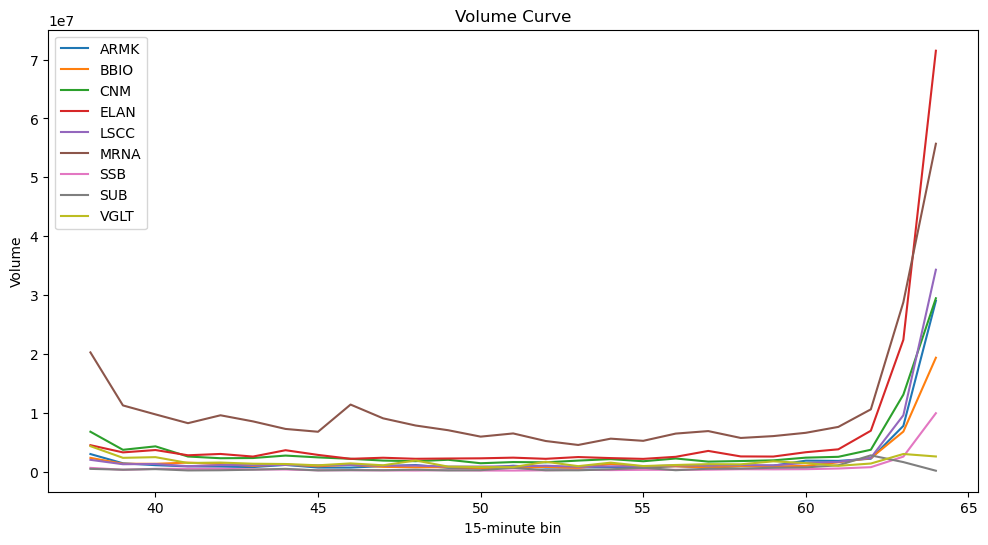

In [65]:
plt.figure(figsize=(12, 6))
for ticker, volume_curve in aggregate_volume_curves.items():
    plt.plot(volume_curve.index, volume_curve.values, label=ticker)

plt.xlabel('15-minute bin')
plt.ylabel('Volume')
plt.legend()
plt.title(f'Volume Curve')
plt.show()

Given the above code, I will select the Moderna stock (MRNA) to plot daily volume curves (since it has the greatest overall volume)

Generate daily volume curves for the Moderna stock (MRNA) using 15 minute bins

In [66]:
volume_curves_by_day = {}
taq_MRNA = taq[taq['SYM_ROOT'] == 'MRNA']
for day in taq['DATE'].unique():
    taq_by_day = taq_MRNA[taq_MRNA['DATE'] == day]
    volume_curve = compute_volume_curve(taq_by_day, 15)
    volume_curves_by_day[day] = volume_curve

Plot daily volume curves and average value on the same axes for MRNA

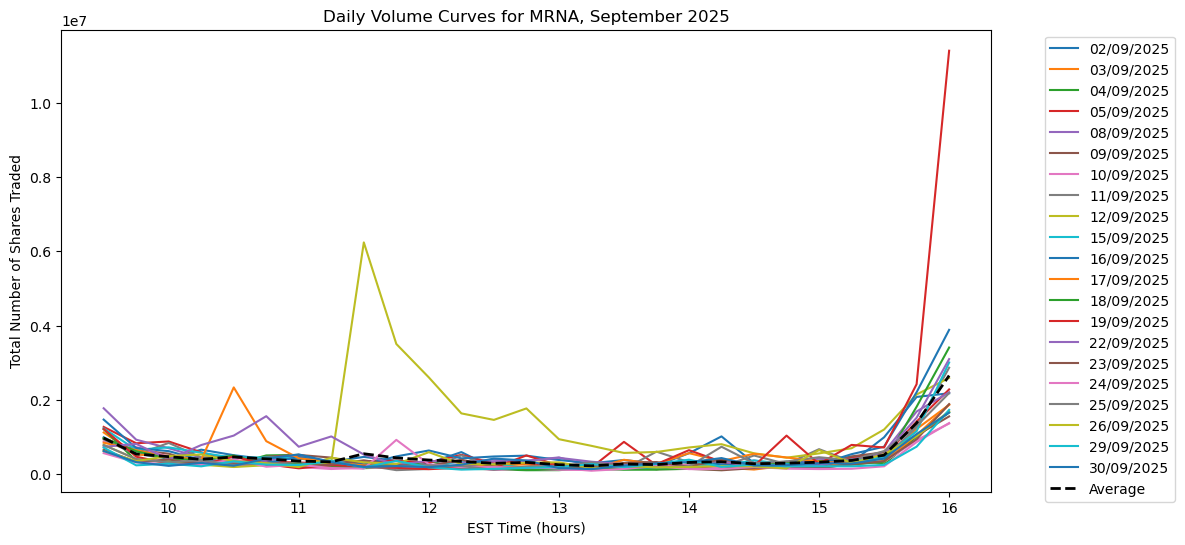

In [71]:
plt.figure(figsize=(12, 6))
for day, volume_curve in volume_curves_by_day.items():
    plt.plot(volume_curve.index * 15 / 60, volume_curve.values, label=day)

# plot average volume curve across all days
average_volume_curve: pd.Series = pd.DataFrame(volume_curves_by_day).mean(axis=1)
plt.plot(average_volume_curve.index * 15 / 60, average_volume_curve.to_numpy(), label='Average', color='black', linewidth=2, linestyle='--')

plt.xlabel('EST Time (hours)')
plt.ylabel('Total Number of Shares Traded')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f'Daily Volume Curves for MRNA, September 2025')
plt.show()

We can see that there are two huge outliars on the 5th and 26th September, where some news must have driven a much-higher-than normal volume. However, since the homework assignment did not mention data filtering, I will leave these in the data set despite recognising they are outliars.

## Part c)

Compute combined volume curve that normalises each stock by its average daily volume and plot